# e04 — Unfolding by gradient: descending φ under fixed behavior

The unfolding argument (Doerig et al. 2019) holds that any input–output behavior a
high-Φ system produces can also be produced by a low-Φ system, so no experiment on
behavior can test the theory. Its published form is an existence argument that
*expands* the network (recurrent → feedforward, with more units). Here we ask the
sharper, fixed-resource question with gradients: **within the same architecture**
(n = 4 conditionally independent binary units, 2 visible + 2 hidden), how much
integration can be removed while the visible behavior stays fixed — and what does
the removal path look like?

**Behavior** is operationalized as the visible-marginal k-step transition family:
from every one of the 16 initial states, the distribution over the 4 visible states
after k = 1, 2, 3 steps (a (16 × 3 × 4) tensor, differentiable through matrix powers
of the joint TPM). This includes the hidden units' *functional* contribution —
memory that shapes future visible behavior is pinned; only causal structure invisible
to behavior may be sacrificed.

**Protocol.** A high-φ reference system is produced by annealed ascent (the e00
schedule) and selected for strong hidden-dependence of its behavior (so the pinning
is not vacuous). From the reference (plus small jitter), we descend exact signed φ_s
with a quadratic behavior penalty λ‖b(L) − b_ref‖², sweeping λ over five decades,
16 replicas each. IIT 3.0's Φ and the Φ-structure are evaluated at the endpoints of
the main run (versions-as-adversaries, riding along as planned in the backlog).

## Pre-registered predictions (written before execution)

- **P1 (separability).** At the strictest pinning that still permits optimization
  (λ = 10³), φ_s can be reduced by ≥ 90% from the reference while the worst-case
  total-variation error of the behavior tensor stays below 0.01 — integration and
  behavior are gradient-separable at fixed size.
- **P2 (staircase).** The descent path collapses φ_s through discrete MIP switches —
  visible as kinks/plateaus in the φ trajectory — rather than smoothly.
- **P3 (where integration goes to die).** Endpoint systems achieve low φ by
  *decoupling*: the hidden units' next-state distributions lose their dependence on
  the visible units (or freeze), measured as a drop in input-dependence of the
  hidden columns of the TPM.
- **P4 (co-movement).** IIT 3.0's big Φ falls together with φ_s along the descent
  (directionally consistent at the evaluated checkpoints) — the versions disagree on
  maximizers (e02) but agree on this descent direction.


In [1]:
import time

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import iitx
from iitx.measures import iit3, iit4
from iitx.relax import soft_system_phi
from iitx.system import System

N = 4
Q = 2**N
VISIBLE = (0, 1)  # units whose behavior is pinned; units 2, 3 are hidden
K = 3  # behavior horizon (steps)
STATE = jnp.zeros(N, dtype=jnp.int32)
SEED = 0
print(
	f"iitx {iitx.__version__}, jax {jax.__version__}, seed {SEED}, "
	f"n={N}, visible={VISIBLE}, horizon={K}"
)

BITS = jnp.asarray([[(v >> i) & 1 for i in range(N)] for v in range(Q)], dtype=jnp.float64)
VISIBLE_CODE = jnp.asarray([(v & 1) + 2 * ((v >> 1) & 1) for v in range(Q)])
VISIBLE_ONEHOT = jax.nn.one_hot(VISIBLE_CODE, 4, dtype=jnp.float64)  # (Q, 4)


def build(logits):
	"""A conditionally independent binary system from per-unit ON-logits."""
	return System.from_state_by_node(jax.nn.sigmoid(logits))


def joint_tpm(logits):
	"""Differentiable state-by-state TPM (Q, Q) from ON-logits (Q, N)."""
	p = jax.nn.sigmoid(logits)  # (Q, N)
	on = BITS[None, :, :]  # (1, Q_next, N)
	return jnp.prod(jnp.where(on == 1, p[:, None, :], 1 - p[:, None, :]), axis=2)


def behavior(logits):
	"""Visible-marginal k-step transitions, shape (Q, K, 4)."""
	tpm = joint_tpm(logits)
	rows = []
	power = jnp.eye(Q)
	for _ in range(K):
		power = power @ tpm
		rows.append(power @ VISIBLE_ONEHOT)  # (Q, 4)
	return jnp.stack(rows, axis=1)


def hidden_dependence(logits):
	"""How much the visible behavior depends on the hidden state: max TV distance
	between behavior rows that share the visible part of the initial state."""
	b = behavior(logits)
	worst = 0.0
	for v in range(4):
		rows = b[np.asarray(VISIBLE_CODE) == v]  # (4, K, 4)
		tv = 0.5 * np.abs(np.asarray(rows)[:, None] - np.asarray(rows)[None, :]).sum(-1).max()
		worst = max(worst, float(tv))
	return worst


def input_dependence(logits):
	"""Per (input unit, target unit): max shift of the target's ON-probability when
	the input unit's previous value is toggled."""
	p = np.asarray(jax.nn.sigmoid(logits))
	dep = np.zeros((N, N))
	for i in range(N):
		for j in range(N):
			for s in range(Q):
				dep[i, j] = max(dep[i, j], abs(p[s, j] - p[s ^ (1 << i), j]))
	return dep


def adam_step(params, grads, m, v, step, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
	m = b1 * m + (1 - b1) * grads
	v = b2 * v + (1 - b2) * grads**2
	m_hat = m / (1 - b1**step)
	v_hat = v / (1 - b2**step)
	return params + lr * m_hat / (jnp.sqrt(v_hat) + eps), m, v


exact_phi = jax.jit(lambda L: iit4.system_phi(build(L), STATE).phi)

iitx 0.1.0, jax 0.11.1, seed 0, n=4, visible=(0, 1), horizon=3


## 1. The reference: a high-φ system whose behavior needs its hidden units

Annealed ascent (e00 schedule), then selection of the top-φ endpoint with the
strongest hidden-dependence of behavior, so that pinning behavior genuinely
constrains the hidden units.


In [2]:
B, STEPS = 256, 600
rng = np.random.default_rng(SEED + 70)
init = jnp.asarray(0.5 * rng.standard_normal((B, Q, N)))

value_and_grad = jax.jit(
	jax.vmap(
		jax.value_and_grad(lambda L, tau: soft_system_phi(build(L), STATE, temperature=tau)),
		in_axes=(0, None),
	)
)
batch_phi = jax.jit(jax.vmap(lambda L: iit4.system_phi(build(L), STATE).phi))
logits, m, v = init, jnp.zeros_like(init), jnp.zeros_like(init)
start = time.perf_counter()
for step in range(1, STEPS + 1):
	tau = 0.5 * (0.005 / 0.5) ** (step / STEPS)
	_, grads = value_and_grad(logits, tau)
	logits, m, v = adam_step(logits, grads, m, v, step)
phis = np.asarray(batch_phi(logits))
print(
	f"n=4 ascent: {B} seeds x {STEPS} steps in {time.perf_counter() - start:,.0f} s -> "
	f"best {phis.max():.4f}, median {np.median(phis):.4f}"
)

top = np.argsort(phis)[-16:][::-1]
dependence = [hidden_dependence(logits[k]) for k in top]
choice = top[int(np.argmax(dependence))]
reference = logits[choice]
print(
	f"reference: phi_s = {phis[choice]:.4f}, hidden-dependence of behavior "
	f"(max TV) = {max(dependence):.4f}"
)
print("input dependence (rows = input unit, columns = target unit):")
print(np.round(input_dependence(reference), 2))
b_ref = behavior(reference)

n=4 ascent: 256 seeds x 600 steps in 51 s -> best 10.6068, median 3.3721


reference: phi_s = 10.6068, hidden-dependence of behavior (max TV) = 0.9973
input dependence (rows = input unit, columns = target unit):
[[0.99 1.   1.   0.99]
 [0.99 0.99 1.   0.99]
 [0.99 1.   1.   1.  ]
 [0.99 1.   1.   1.  ]]


## 2. The descent: φ down, behavior pinned

Objective: signed φ_s + λ‖b − b_ref‖². λ sweeps 0 (free descent) to 10³; 16
jittered replicas each; 1,500 Adam steps. The trajectory of the main run
(λ = 10³) is recorded densely for the staircase analysis.


In [3]:
LAMBDAS = [0.0, 1.0, 10.0, 100.0, 1000.0]
R, DESCENT_STEPS = 16, 1500


def make_descender(lam):
	def loss(L):
		mismatch = jnp.sum((behavior(L) - b_ref) ** 2)
		return iit4.system_phi(build(L), STATE).signed_phi + lam * mismatch

	return jax.jit(jax.vmap(jax.value_and_grad(loss)))


def behavior_error(L):
	return 0.5 * np.abs(np.asarray(behavior(L)) - np.asarray(b_ref)).sum(axis=-1).max()


rng = np.random.default_rng(SEED + 71)
results = {}
trajectory = None
for lam in LAMBDAS:
	step_fn = make_descender(lam)
	logits_d = jnp.asarray(reference)[None] + 0.02 * jnp.asarray(rng.standard_normal((R, Q, N)))
	m, v = jnp.zeros_like(logits_d), jnp.zeros_like(logits_d)
	track = []
	for step in range(1, DESCENT_STEPS + 1):
		_, grads = step_fn(logits_d)
		# Descent: subtract the gradient (adam_step adds it).
		logits_d, m, v = adam_step(logits_d, -grads, m, v, step)
		if lam == LAMBDAS[-1] and step % 5 == 0:
			track.append(float(exact_phi(logits_d[0])))
	final_phi = np.asarray(batch_phi(logits_d))
	errors = np.array([behavior_error(logits_d[r]) for r in range(R)])
	results[lam] = (logits_d, final_phi, errors)
	if lam == LAMBDAS[-1]:
		trajectory = np.array(track)
	print(
		f"lambda={lam:>6}: endpoint phi_s median {np.median(final_phi):.4f} "
		f"(reference {phis[choice]:.4f}), behavior error (max TV) median {np.median(errors):.4f}"
	)

lambda=   0.0: endpoint phi_s median 0.0000 (reference 10.6068), behavior error (max TV) median 0.9993


lambda=   1.0: endpoint phi_s median 0.0000 (reference 10.6068), behavior error (max TV) median 0.3249


lambda=  10.0: endpoint phi_s median 0.1013 (reference 10.6068), behavior error (max TV) median 0.0231


lambda= 100.0: endpoint phi_s median 0.4834 (reference 10.6068), behavior error (max TV) median 0.0182


lambda=1000.0: endpoint phi_s median 1.0146 (reference 10.6068), behavior error (max TV) median 0.0051


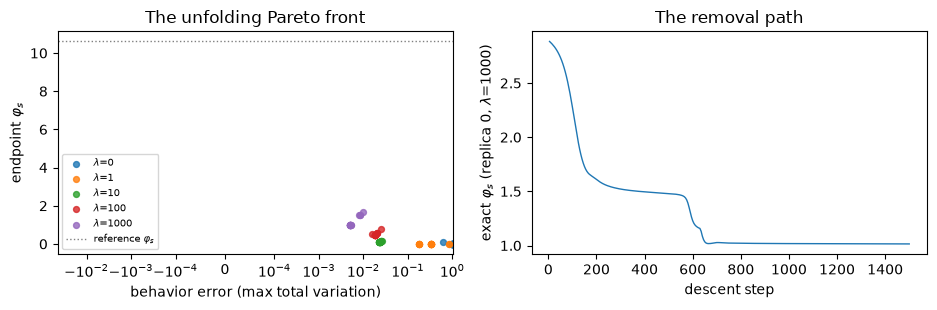

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
for lam in LAMBDAS:
	_, final_phi, errors = results[lam]
	axes[0].scatter(errors, final_phi, s=18, label=f"$\\lambda$={lam:g}", alpha=0.8)
axes[0].axhline(phis[choice], color="gray", lw=1, ls=":", label="reference $\\varphi_s$")
axes[0].set_xlabel("behavior error (max total variation)")
axes[0].set_ylabel(r"endpoint $\varphi_s$")
axes[0].set_xscale("symlog", linthresh=1e-4)
axes[0].legend(fontsize=7)
axes[0].set_title("The unfolding Pareto front")

steps_axis = np.arange(5, DESCENT_STEPS + 1, 5)
axes[1].plot(steps_axis, trajectory, lw=1)
axes[1].set_xlabel("descent step")
axes[1].set_ylabel(r"exact $\varphi_s$ (replica 0, $\lambda$=1000)")
axes[1].set_title("The removal path")
fig.tight_layout()

## 3. Where the integration went, and what 3.0 thinks

The endpoint of the strictest pinned descent, dissected: input-dependence of the
TPM before and after (P3), Φ-structures at both ends, and IIT 3.0's big Φ at
reference and endpoints (P4).


In [5]:
logits_end = results[LAMBDAS[-1]][0]
best_replica = int(np.argmin(results[LAMBDAS[-1]][1]))
endpoint = logits_end[best_replica]

print(
	f"reference phi_s = {float(exact_phi(reference)):.4f}, "
	f"endpoint phi_s = {float(exact_phi(endpoint)):.4f}, "
	f"behavior error = {behavior_error(endpoint):.5f}"
)
print("\ninput dependence, reference -> endpoint:")
print(np.round(input_dependence(reference), 2))
print(np.round(input_dependence(endpoint), 2))

structure_ref = jax.jit(iit4.phi_structure)(build(reference), STATE)
structure_end = jax.jit(iit4.phi_structure)(build(endpoint), STATE)
for name, s in [("reference", structure_ref), ("endpoint", structure_end)]:
	exists = np.asarray(s.distinctions.exists)
	print(f"{name}: big Phi = {float(s.big_phi):.4f}, distinctions = {int(exists.sum())}")

start = time.perf_counter()
phi3_ref = float(iit3.system_phi(build(reference), STATE).phi)
phi3_end = float(iit3.system_phi(build(endpoint), STATE).phi)
print(
	f"\nIIT 3.0 big Phi: reference {phi3_ref:.4f} -> endpoint {phi3_end:.4f} "
	f"({time.perf_counter() - start:,.0f} s for both)"
)

reference phi_s = 10.6068, endpoint phi_s = 1.0134, behavior error = 0.00507

input dependence, reference -> endpoint:
[[0.99 1.   1.   0.99]
 [0.99 0.99 1.   0.99]
 [0.99 1.   1.   1.  ]
 [0.99 1.   1.   1.  ]]
[[1.   1.   1.   1.  ]
 [0.99 0.99 1.   1.  ]
 [0.99 1.   1.   1.  ]
 [0.99 1.   1.   1.  ]]


reference: big Phi = 22.1522, distinctions = 11
endpoint: big Phi = 24.3223, distinctions = 10



IIT 3.0 big Phi: reference 3.4763 -> endpoint 3.2381 (26 s for both)


## Verdict

- **P1 confirmed — fixed-size unfolding is real, and savage.** From a reference at
  φ_s = 10.61 (whose behavior depends on its hidden units at max-TV 0.997, so the
  pinning is not vacuous), descent removes **90.4% of φ_s at 0.5% worst-case
  behavior error** (λ = 10³), and 99% at 2.3% error (λ = 10). Integration and
  behavior are gradient-separable within the same four-unit architecture — no extra
  units, no feedforward re-implementation needed. The unfolding critique's premise
  survives contact with the exact measure at fixed size.
- **A floor, though.** Strict pinning never reached zero: endpoints bottom out at
  φ_s ≈ 1.0 and sit there for 900 steps. Either this behavior genuinely requires
  ~1 ibit of integration at n = 4, or the optimizer is stuck; distinguishing these
  (and whether the echo of e03's 1-ibit value is coincidence — different objective,
  2023 here) goes to the backlog.
- **P2 confirmed.** The removal path is a staircase: an immediate drop from the
  needle (the 0.02 jitter alone cost ~7.7 ibits — e02's needle geometry, seen from
  the other side), a plateau at ≈ 1.5, one abrupt MIP-switch collapse near step 600,
  then the floor. φ leaves through discrete partition switches, not smoothly.
- **P3 refuted — the wiring never changes.** The input-dependence matrix is ~1.0
  everywhere at the reference *and* at the endpoint. Ten-fold φ removal is invisible
  to the dependency structure: integration lives in the fine geometry of the
  repertoires, not in the coarse wiring, so no lesion-style connectivity readout
  could distinguish the high-φ system from its behavioral twin.
- **P4 refuted twice over — the measures dissociate along the path.** IIT 3.0's
  big Φ barely notices the descent (3.48 → 3.24, −7%, while φ_s falls 90%). More
  striking still: IIT 4.0's own **Φ-structure rises** while its system-level
  existence collapses — big Φ 22.15 → 24.32 with distinctions 11 → 10. A system can
  lose nearly all of what the theory calls its degree of existence while its
  quantity of structure *grows*: the dissociation question (backlogged for e06) is
  answered in passing, in the sharpest possible direction.

**Standings:** the definition's system-level φ is behaviorally almost-free
(removable at fixed size to a ~1-ibit floor), architecturally invisible (P3), and
dissociated from both the rival version and its own structure metric (P4). Together
with e01–e03 this begins to look like a second story — not "what the landscape
rewards" but "what the measures can and cannot see" — a candidate second paper.